In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# CONFIGURATION


In [24]:
OXCGRT_FILE = "OxCGRT_compact_national_v1.csv"
ACLED_FILE = "repression_lagged_data_up_to-2024-10-24_0.xlsx"
POLITICAL_FILE = "number_of_political_violence_events_by_country-month-year_as-of-24Oct2025_0.xlsx"
DEMO_FILE = "number_of_demonstration_events_by_country-year_as-of-24Oct2025_0.xlsx"
OUTPUT_FILE = "final_merged_dataset.csv"


# STEP 1: PROCESS OxCGRT (Restrictions)


In [25]:
print("\n--- STEP 1: Processing OxCGRT Data ---")
ox_cols = ["CountryName", "Jurisdiction", "Date", "StringencyIndex_Average"]

df_ox = pd.read_csv(OXCGRT_FILE, usecols=ox_cols)

if "Jurisdiction" in df_ox.columns and "NAT_TOTAL" in df_ox["Jurisdiction"].unique():
    df_ox = df_ox[df_ox["Jurisdiction"] == "NAT_TOTAL"].copy()

df_ox["Date"] = pd.to_datetime(df_ox["Date"], format="%Y%m%d")
df_ox.set_index("Date", inplace=True)
df_ox_monthly = df_ox.groupby("CountryName")["StringencyIndex_Average"].resample("ME").mean().reset_index()

df_ox_monthly.rename(columns={"StringencyIndex_Average": "StringencyIndex", "Date": "Month"}, inplace=True)
print(f"OxCGRT Processed: {len(df_ox_monthly)} rows")


--- STEP 1: Processing OxCGRT Data ---
OxCGRT Processed: 6660 rows



# STEP 2: PROCESS REPRESSION (Target)


In [26]:
print("\n--- STEP 2: Processing Repression Data ---")
rep_cols = ["EVENT_DATE", "COUNTRY", "EVENT_ID_CNTY", "FATALITIES"]

df_rep = pd.read_excel(ACLED_FILE, usecols=rep_cols)

df_rep.rename(columns={
    "EVENT_DATE": "event_date",
    "COUNTRY": "CountryName",
    "EVENT_ID_CNTY": "RepressionEvents",
    "FATALITIES": "RepressionFatalities"
}, inplace=True)

df_rep["event_date"] = pd.to_datetime(df_rep["event_date"])
df_rep["Month"] = df_rep["event_date"].dt.to_period("M").dt.to_timestamp(freq="M")

df_rep_monthly = df_rep.groupby(["CountryName", "Month"]).agg({
    "RepressionEvents": "count",
    "RepressionFatalities": "sum"
}).reset_index()
print(f"Repression Processed: {len(df_rep_monthly)} rows")


--- STEP 2: Processing Repression Data ---
Repression Processed: 5959 rows



# STEP 3: PROCESS POLITICAL VIOLENCE (Context)


In [27]:
print("\n--- STEP 3: Processing Political Violence ---")
pol_cols = ["COUNTRY", "MONTH", "YEAR", "EVENTS"]

df_pol = pd.read_excel(POLITICAL_FILE, usecols=pol_cols)

df_pol["DateStr"] = df_pol["MONTH"] + " " + df_pol["YEAR"].astype(str)

df_pol["Month"] = pd.to_datetime(df_pol["DateStr"], format="%B %Y") + pd.offsets.MonthEnd(0)

df_pol.rename(columns={"COUNTRY": "CountryName", "EVENTS": "PoliticalViolenceEvents"}, inplace=True)
df_pol = df_pol[["CountryName", "Month", "PoliticalViolenceEvents"]]

print(f"Political Violence Processed: {len(df_pol)} rows")


--- STEP 3: Processing Political Violence ---
Political Violence Processed: 28069 rows



# STEP 4: PROCESS DEMONSTRATIONS (Control)


In [28]:
print("\n--- STEP 4: Processing Demonstrations ---")
dem_cols = ["COUNTRY", "YEAR", "EVENTS"]

df_dem = pd.read_excel(DEMO_FILE, usecols=dem_cols)

df_dem.rename(columns={
    "COUNTRY": "CountryName", 
    "YEAR": "Year", 
    "EVENTS": "AnnualDemonstrations"
}, inplace=True)

print(f"Demonstrations Processed: {len(df_dem)} rows")


--- STEP 4: Processing Demonstrations ---
Demonstrations Processed: 2726 rows



# STEP 5: MERGE ALL DATASETS


In [29]:
print("\n--- STEP 5: Merging Everything ---")

df_main = pd.merge(df_rep_monthly, df_ox_monthly, on=["CountryName", "Month"], how="inner")

df_main = pd.merge(df_main, df_pol, on=["CountryName", "Month"], how="left")
df_main["PoliticalViolenceEvents"] = df_main["PoliticalViolenceEvents"].fillna(0)

df_main["Year"] = df_main["Month"].dt.year
df_main = pd.merge(df_main, df_dem, on=["CountryName", "Year"], how="left")
df_main["AnnualDemonstrations"] = df_main["AnnualDemonstrations"].fillna(0)

df_main.to_csv(OUTPUT_FILE, index=False)
print(f"FINAL MERGE COMPLETE. Saved to {OUTPUT_FILE}")
print(f"Total Data Points: {len(df_main)}")


--- STEP 5: Merging Everything ---
FINAL MERGE COMPLETE. Saved to final_merged_dataset.csv
Total Data Points: 3559


# STEP 6: DESCRIPTIVE STATISTICS


Variable: StringencyIndex
  - Mean: 44.39
  - Std Dev: 24.98
  - Range: 0.00 to 100.00 (Span: 100.00)

Variable: RepressionEvents
  - Mean: 10.31
  - Std Dev: 22.13
  - Range: 1.00 to 565.00 (Span: 564.00)

Variable: PoliticalViolenceEvents
  - Mean: 93.12
  - Std Dev: 277.99
  - Range: 0.00 to 5113.00 (Span: 5113.00)

Variable: AnnualDemonstrations
  - Mean: 1415.12
  - Std Dev: 2641.80
  - Range: 0.00 to 22363.00 (Span: 22363.00)

   T-TEST RESULTS (High vs Low Groups)

Test: Does High 'StringencyIndex' lead to more Repression?
  - Low Group Mean (RepressionEvents): 9.48
  - High Group Mean (RepressionEvents): 11.13
  - T-Statistic: 2.2261
  - P-Value: 2.6076e-02
  - Result: **SIGNIFICANT**

Test: Does High 'PoliticalViolenceEvents' lead to more Repression?
  - Low Group Mean (RepressionEvents): 3.77
  - High Group Mean (RepressionEvents): 16.96
  - T-Statistic: 18.4553
  - P-Value: 5.8610e-70
  - Result: **SIGNIFICANT**

Test: Does High 'AnnualDemonstrations' lead to more Repressio

/var/folders/vk/xb_7sn4974n_d298zvyy1c340000gn/T/ipykernel_13107/2960966708.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Low", "High"], y=[group_low.mean(), group_high.mean()], palette=["skyblue", "salmon"])
/var/folders/vk/xb_7sn4974n_d298zvyy1c340000gn/T/ipykernel_13107/2960966708.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Low", "High"], y=[group_low.mean(), group_high.mean()], palette=["skyblue", "salmon"])
/var/folders/vk/xb_7sn4974n_d298zvyy1c340000gn/T/ipykernel_13107/2960966708.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

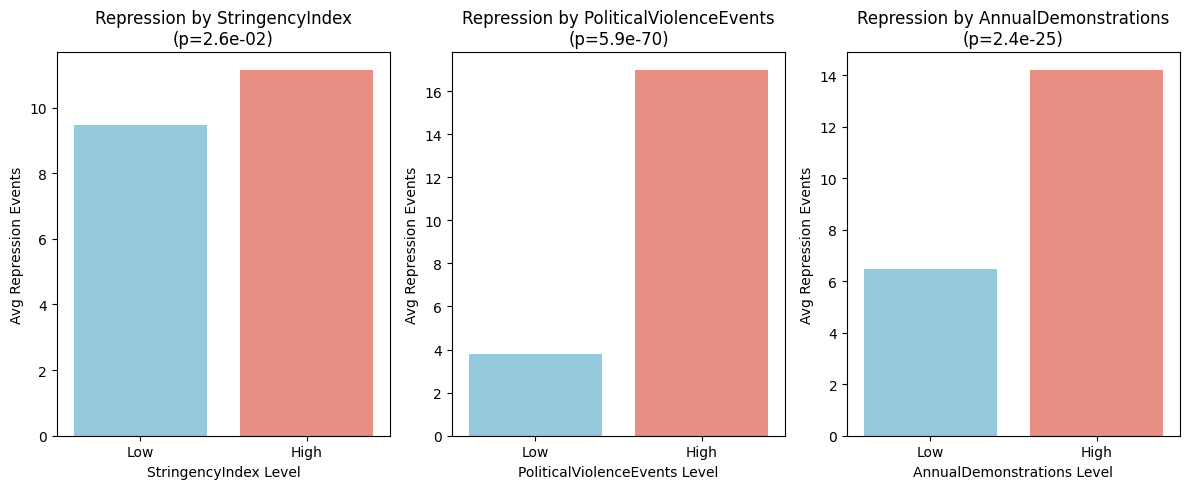

In [30]:
stats_summary = []
variables = ["StringencyIndex", "RepressionEvents", "PoliticalViolenceEvents", "AnnualDemonstrations"]

for var in variables:
    mean_val = df_main[var].mean()
    std_val = df_main[var].std()
    min_val = df_main[var].min()
    max_val = df_main[var].max()
    range_val = max_val - min_val
    
    print(f"\nVariable: {var}")
    print(f"  - Mean: {mean_val:.2f}")
    print(f"  - Std Dev: {std_val:.2f}")
    print(f"  - Range: {min_val:.2f} to {max_val:.2f} (Span: {range_val:.2f})")
    
    stats_summary.append({
        "Variable": var, "Mean": mean_val, "Std": std_val, "Min": min_val, "Max": max_val
    })

print("\n" + "="*40)
print("   T-TEST RESULTS (High vs Low Groups)")

results = []

target = "RepressionEvents"
features = ["StringencyIndex", "PoliticalViolenceEvents", "AnnualDemonstrations"]

plt.figure(figsize=(12, 5))
plot_idx = 1

for feature in features:
    # Split into High and Low groups based on Median
    median_val = df_main[feature].median()
    group_low = df_main[df_main[feature] <= median_val][target]
    group_high = df_main[df_main[feature] > median_val][target]
    
    # Perform T-Test
    t_stat, p_val = stats.ttest_ind(group_high, group_low, equal_var=False)
    
    print(f"\nTest: Does High '{feature}' lead to more Repression?")
    print(f"  - Low Group Mean ({target}): {group_low.mean():.2f}")
    print(f"  - High Group Mean ({target}): {group_high.mean():.2f}")
    print(f"  - T-Statistic: {t_stat:.4f}")
    print(f"  - P-Value: {p_val:.4e}")
    
    sig = "**SIGNIFICANT**" if p_val < 0.05 else "Not Significant"
    print(f"  - Result: {sig}")
    
    # Plotting for Readability
    plt.subplot(1, 3, plot_idx)
    sns.barplot(x=["Low", "High"], y=[group_low.mean(), group_high.mean()], palette=["skyblue", "salmon"])
    plt.title(f"Repression by {feature}\n(p={p_val:.1e})")
    plt.ylabel("Avg Repression Events")
    plt.xlabel(f"{feature} Level")
    plot_idx += 1

plt.tight_layout()
plt.show()


# STEP 7: ANALYSIS & VISUALIZATION



--- STEP 6: Exploratory Analysis & Results ---


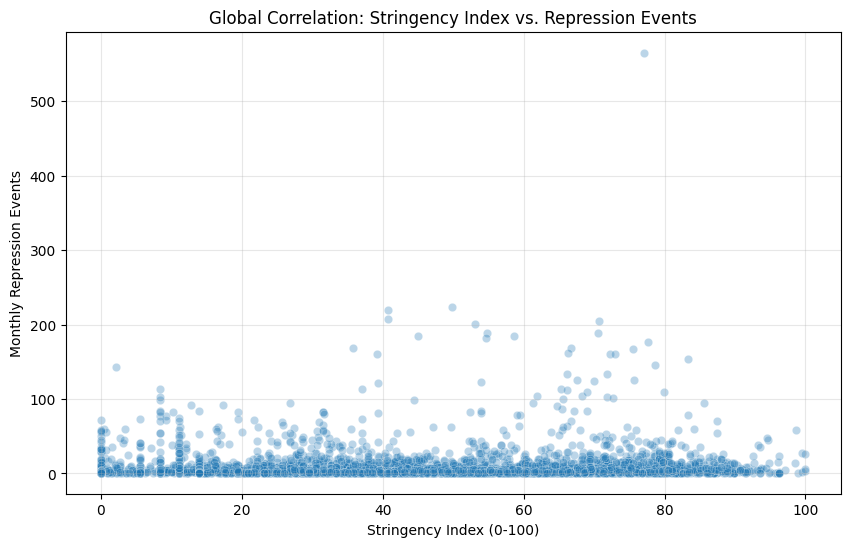

Generating plots for top 3 active countries: ['Myanmar', 'India', 'Afghanistan']


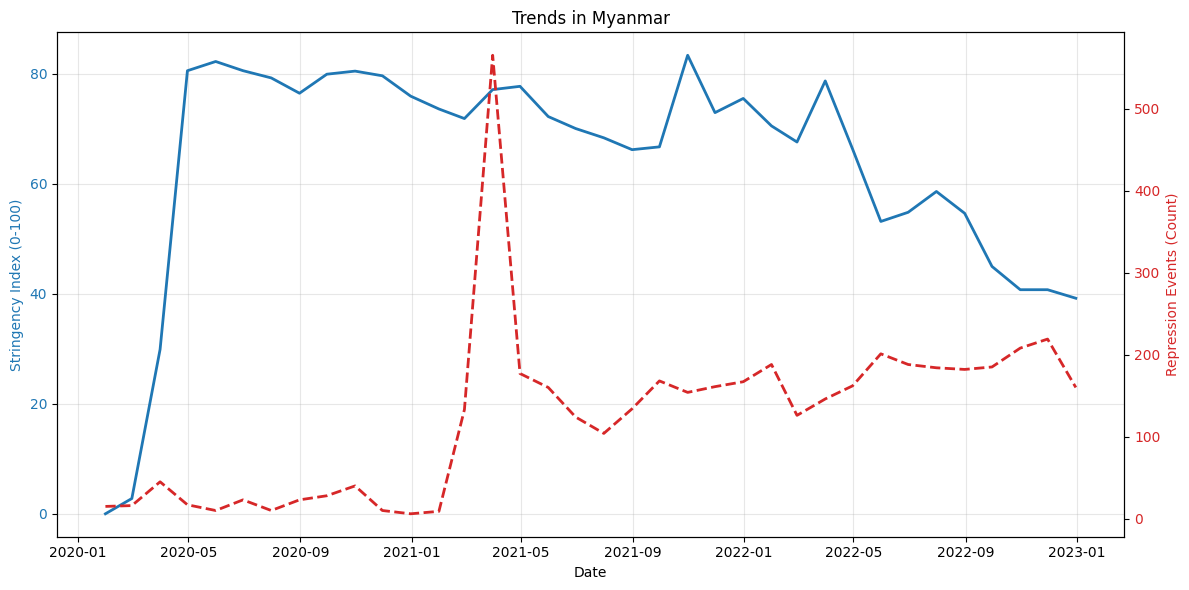

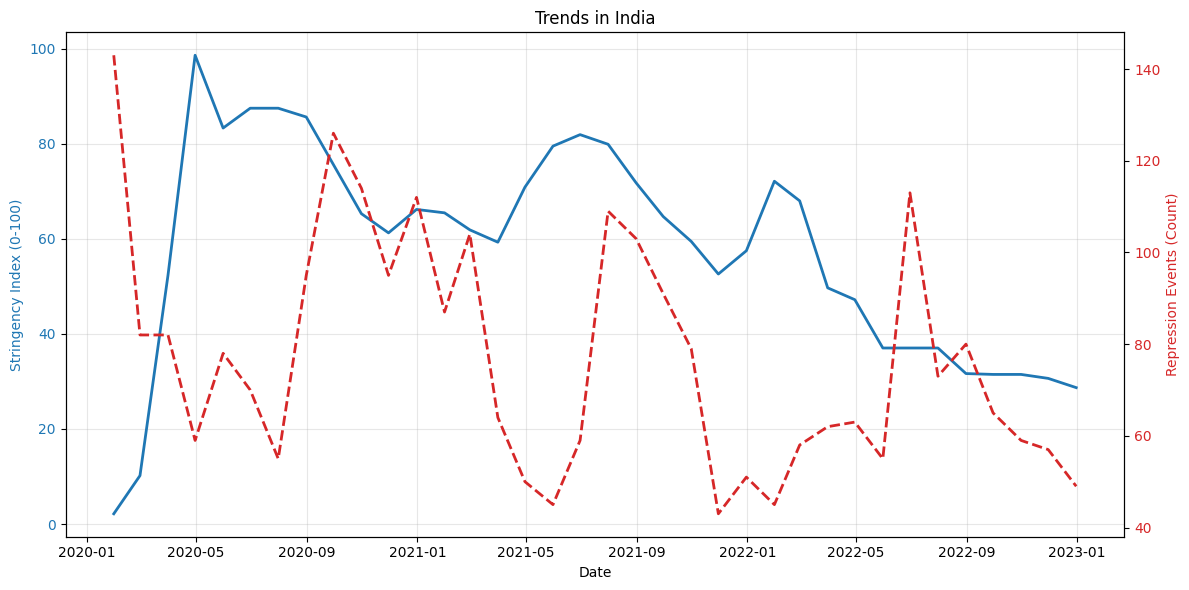

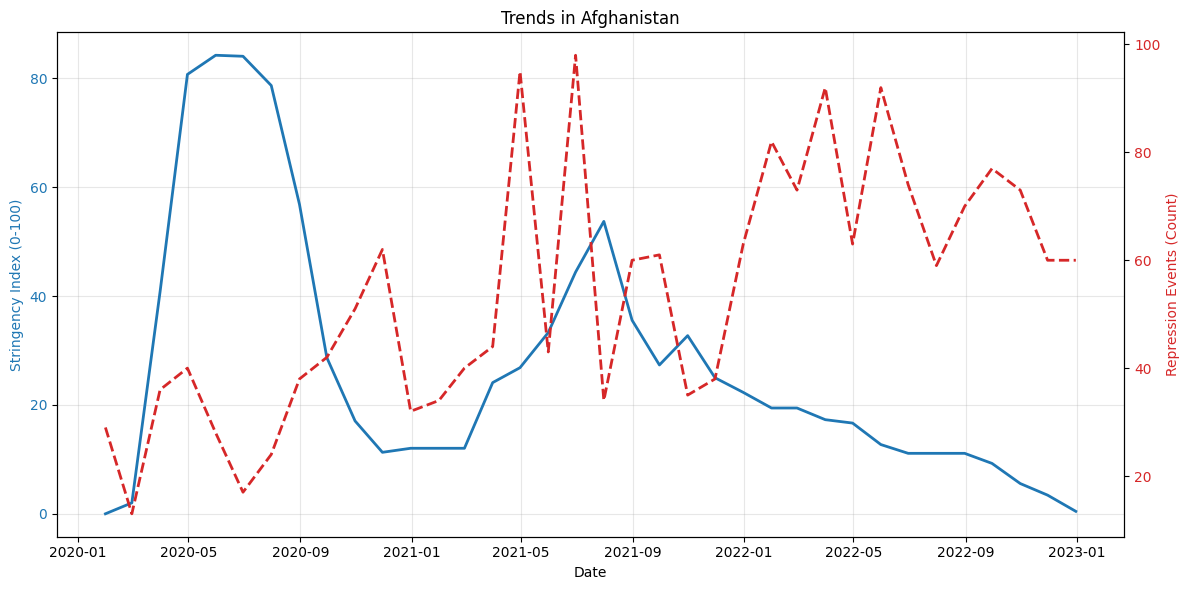

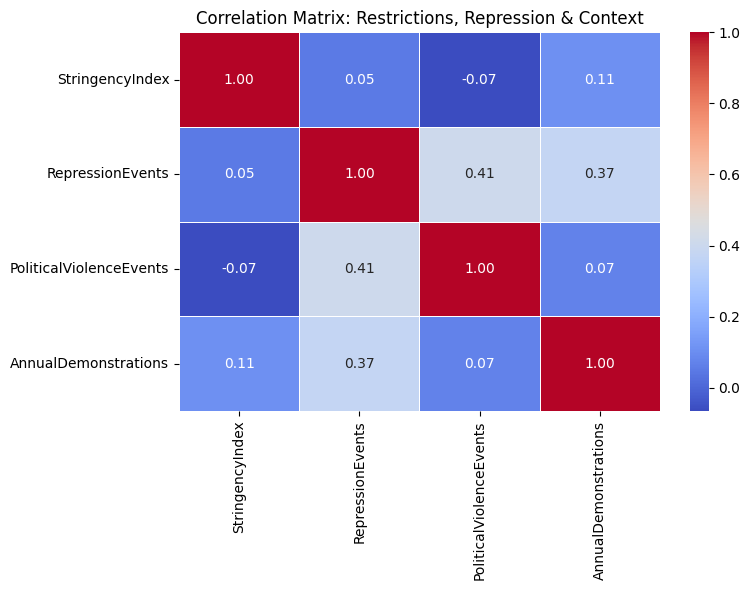

In [31]:
print("\n--- STEP 6: Exploratory Analysis & Results ---")

# 1. Global Correlation Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_main, x="StringencyIndex", y="RepressionEvents", alpha=0.3)
plt.title("Global Correlation: Stringency Index vs. Repression Events")
plt.xlabel("Stringency Index (0-100)")
plt.ylabel("Monthly Repression Events")
plt.grid(True, alpha=0.3)
plt.show()

# 2. Trend Plot for Top Countries
def plot_country_trend(country_name):
    data = df_main[df_main["CountryName"] == country_name]
    
    if len(data) == 0:
        print(f"No data found for {country_name}")
        return

    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stringency Index (0-100)', color=color)
    ax1.plot(data['Month'], data['StringencyIndex'], color=color, linewidth=2, label='Lockdown Stringency')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Repression Events (Count)', color=color)
    ax2.plot(data['Month'], data['RepressionEvents'], color=color, linestyle='--', linewidth=2, label='Repression Events')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"Trends in {country_name}")
    fig.tight_layout()
    plt.show()

# Automatically find the top 3 countries with the most repression events
top_countries = df_main.groupby("CountryName")["RepressionEvents"].sum().sort_values(ascending=False).head(3).index.tolist()
print(f"Generating plots for top 3 active countries: {top_countries}")
for country in top_countries:
    plot_country_trend(country)

# 3. Correlation Heatmap 
plt.figure(figsize=(8, 6))
corr_cols = ["StringencyIndex", "RepressionEvents", "PoliticalViolenceEvents", "AnnualDemonstrations"]
corr_matrix = df_main[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Restrictions, Repression & Context")
plt.tight_layout()
plt.show()



# STEP 8: HYPOTHESIS TESTING AND RESULTS 


In [32]:
print("\n--- HYPOTHESIS TESTING ---")

corr, p_value = stats.pearsonr(df_main['StringencyIndex'], df_main['RepressionEvents'])

print(f"Null Hypothesis (H0): There is NO correlation between Stringency and Repression.")
print(f"Alternative Hypothesis (H1): There IS a significant correlation.")
print("-" * 40)
print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("RESULT: We REJECT the Null Hypothesis.")
    print("There is a statistically significant relationship between restrictions and repression.")
else:
    print("RESULT: We FAIL TO REJECT the Null Hypothesis.")
    print("We did not find a statistically significant relationship.")

print("\n--- Correlation Matrix (All Variables) ---")
corr_cols = ["StringencyIndex", "RepressionEvents", "PoliticalViolenceEvents", "AnnualDemonstrations"]
print(df_main[corr_cols].corr())

print("\n--- Analysis Complete ---")


--- HYPOTHESIS TESTING ---
Null Hypothesis (H0): There is NO correlation between Stringency and Repression.
Alternative Hypothesis (H1): There IS a significant correlation.
----------------------------------------
Pearson Correlation Coefficient: 0.0489
P-value: 3.5457e-03
RESULT: We REJECT the Null Hypothesis.
There is a statistically significant relationship between restrictions and repression.

--- Correlation Matrix (All Variables) ---
                         StringencyIndex  RepressionEvents  \
StringencyIndex                 1.000000          0.048867   
RepressionEvents                0.048867          1.000000   
PoliticalViolenceEvents        -0.065182          0.408288   
AnnualDemonstrations            0.108339          0.371950   

                         PoliticalViolenceEvents  AnnualDemonstrations  
StringencyIndex                        -0.065182              0.108339  
RepressionEvents                        0.408288              0.371950  
PoliticalViolenceEvents  

/opt/anaconda3/envs/DSA201/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
